### Identifying the Top 3 Busiest Areas (Memory Optimization)
To avoid crashing the system's memory with the massive 20GB dataset, we processed the files piece by piece (in chunks). Instead of loading all the raw data at once, we strictly loaded only the `SquareID` and `Internet` traffic columns. As the code read through each small chunk, it kept a running "scoreboard" of the total traffic for each area across all 62 days. Once all files were read, we simply sorted this scoreboard to reveal the three geographical areas with the highest overall internet usage.

In [4]:
import pandas as pd
import glob
import os

file_pattern = '/kaggle/input/datasets/arsenekabasinga/milan-telecom-traffic-2013/dataverse_files/*.txt'
file_list = glob.glob(file_pattern)

# Creating an empty Pandas Series to act as our "Master Scoreboard"
master_traffic_totals = pd.Series(dtype=float)

# Defining  column names (Standard for the Milan Telecom Dataset)
col_names = ['SquareID', 'TimeInterval', 'CountryCode', 'SMSin', 'SMSout', 'Callin', 'Callout', 'Internet']

print(f"Found {len(file_list)} files. Starting processing...")

# Looping through every single file
for file in file_list:
    print(f"Processing {os.path.basename(file)}...")
    
    # Reading the file in chunks of 100,000 rows so we never crash the RAM
    chunk_iterator = pd.read_csv(file, sep='\t', names=col_names, chunksize=100000, 
                                 usecols=['SquareID', 'Internet']) # Only load the 2 columns 
    
    for chunk in chunk_iterator:
        # Filling any missing Internet values with 0
        chunk['Internet'] = chunk['Internet'].fillna(0)
        
        # Grouping by Square ID and sum the traffic for this specific chunk
        chunk_sum = chunk.groupby('SquareID')['Internet'].sum()
        
        # Adding this chunk's sum to our Master Scoreboard
        master_traffic_totals = master_traffic_totals.add(chunk_sum, fill_value=0)

# Finding the Top 3 Geographical Areas
top_3_areas = master_traffic_totals.nlargest(3)


print("The Top 3 Square IDs by Total Internet Traffic are:")
print(top_3_areas)

Found 62 files. Starting processing...
Processing sms-call-internet-mi-2013-11-16.txt...
Processing sms-call-internet-mi-2013-12-16.txt...
Processing sms-call-internet-mi-2013-11-13.txt...
Processing sms-call-internet-mi-2013-12-30.txt...
Processing sms-call-internet-mi-2013-11-02.txt...
Processing sms-call-internet-mi-2013-11-30.txt...
Processing sms-call-internet-mi-2013-12-04.txt...
Processing sms-call-internet-mi-2013-12-18.txt...
Processing sms-call-internet-mi-2013-12-31.txt...
Processing sms-call-internet-mi-2013-12-11.txt...
Processing sms-call-internet-mi-2013-12-10.txt...
Processing sms-call-internet-mi-2013-11-08.txt...
Processing sms-call-internet-mi-2013-11-03.txt...
Processing sms-call-internet-mi-2013-11-17.txt...
Processing sms-call-internet-mi-2013-11-06.txt...
Processing sms-call-internet-mi-2013-11-23.txt...
Processing sms-call-internet-mi-2013-11-21.txt...
Processing sms-call-internet-mi-2013-11-19.txt...
Processing sms-call-internet-mi-2013-12-21.txt...
Processing 

### Extracting the Target Dataset (Data Filtering)
Once we identified our top three busiest areas (alongside the two specific areas assigned by the instructor), we needed a lightweight dataset for our analysis and forecasting models. We looped through the raw files one last time, completely ignoring the thousands of irrelevant geographical squares, and grabbed only the records belonging to our five target areas. We saved this filtered data into a new, tiny CSV file (`filtered_target_squares.csv`). This allows us to work efficiently and never have to process the heavy 20GB dataset again.

In [5]:
import pandas as pd
import glob
import os

# Setting up our paths and targets
file_pattern = '/kaggle/input/datasets/arsenekabasinga/milan-telecom-traffic-2013/dataverse_files/*.txt'
file_list = glob.glob(file_pattern)

col_names = ['SquareID', 'TimeInterval', 'CountryCode', 'SMSin', 'SMSout', 'Callin', 'Callout', 'Internet']
target_squares = [5161, 5059, 5259, 4159, 4556]
output_filename = '/kaggle/working/filtered_target_squares.csv'

print("Starting data extraction for target squares.")

# We use a flag so we only write the column headers once at the very top of the file
header_written = False

# Looping through the files 
if len(file_list) > 0:
    for file in file_list:
        chunk_iterator = pd.read_csv(file, sep='\t', names=col_names, chunksize=100000, 
                                     usecols=['SquareID', 'TimeInterval', 'Internet']) 
        
        for chunk in chunk_iterator:
            filtered_chunk = chunk[chunk['SquareID'].isin(target_squares)]
            if not filtered_chunk.empty:
                filtered_chunk.to_csv(output_filename, mode='a', index=False, header=not header_written)
                header_written = True

    print(f"--- Extraction complete! ---")
    print(f"Tiny dataset successfully saved to: {output_filename}")
else:
    print("ERROR: Could not find the files.")

Starting data extraction for target squares.
--- Extraction complete! ---
Tiny dataset successfully saved to: /kaggle/working/filtered_target_squares.csv


## Exploratory Data Analysis (EDA)

The objective of this phase is to uncover the underlying patterns in the Milan Internet traffic dataset before we begin forecasting. By visually inspecting the data, we can understand its behavior and make informed modeling decisions. In this section, we will:

1. **Analyze the Overall Distribution:** Observe how traffic is concentrated across all geographical squares to understand the city's broader network demand.
2. **Visualize Temporal Patterns:** Plot a two-week window for our five target areas to identify daily or weekly cycles (seasonality) and contrast the high-traffic hubs against the assigned test squares.
3. **Analyze Autocorrelation (Next Steps):** Use ACF and PACF plots on our busiest square to scientifically determine how past traffic influences future traffic, which will dictate the memory window size for our deep learning models.

### Overall Traffic Distribution
This code visualizes the total internet traffic accumulated by each of the ~10,000 squares over the entire two-month period. We use a histogram to show how the traffic is distributed across the city. This helps us confirm if the network demand is evenly spread or heavily skewed toward a few major hubs.

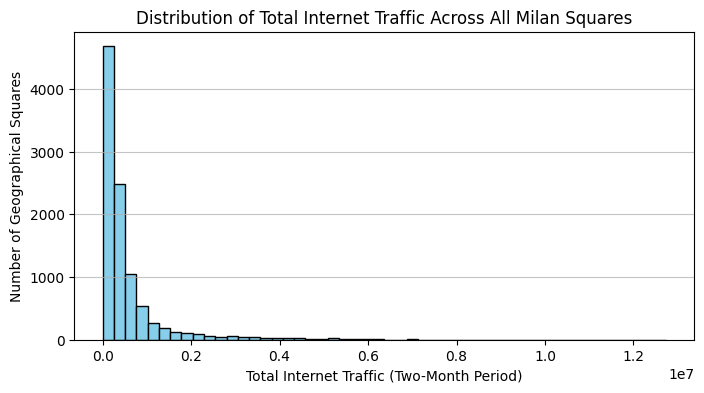

In [11]:
import matplotlib.pyplot as plt

# Plotting the distribution of total traffic across all ~10,000 areas
plt.figure(figsize=(8, 4))
master_traffic_totals.plot(kind='hist', bins=50, color='skyblue', edgecolor='black')

plt.title('Distribution of Total Internet Traffic Across All Milan Squares')
plt.xlabel('Total Internet Traffic (Two-Month Period)')
plt.ylabel('Number of Geographical Squares')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Temporal Dynamics (First Two Weeks)
Here, we load our newly filtered dataset and convert the raw UNIX timestamps into standard, readable dates. We then filter the data to display only the first two weeks (Nov 1 - Nov 14, 2013) for our five target squares. This allows us to visually inspect the data for recurring patterns (like daily peaks and overnight drops) and compare the massive scale of the top 3 squares against Squares 4159 and 4556.

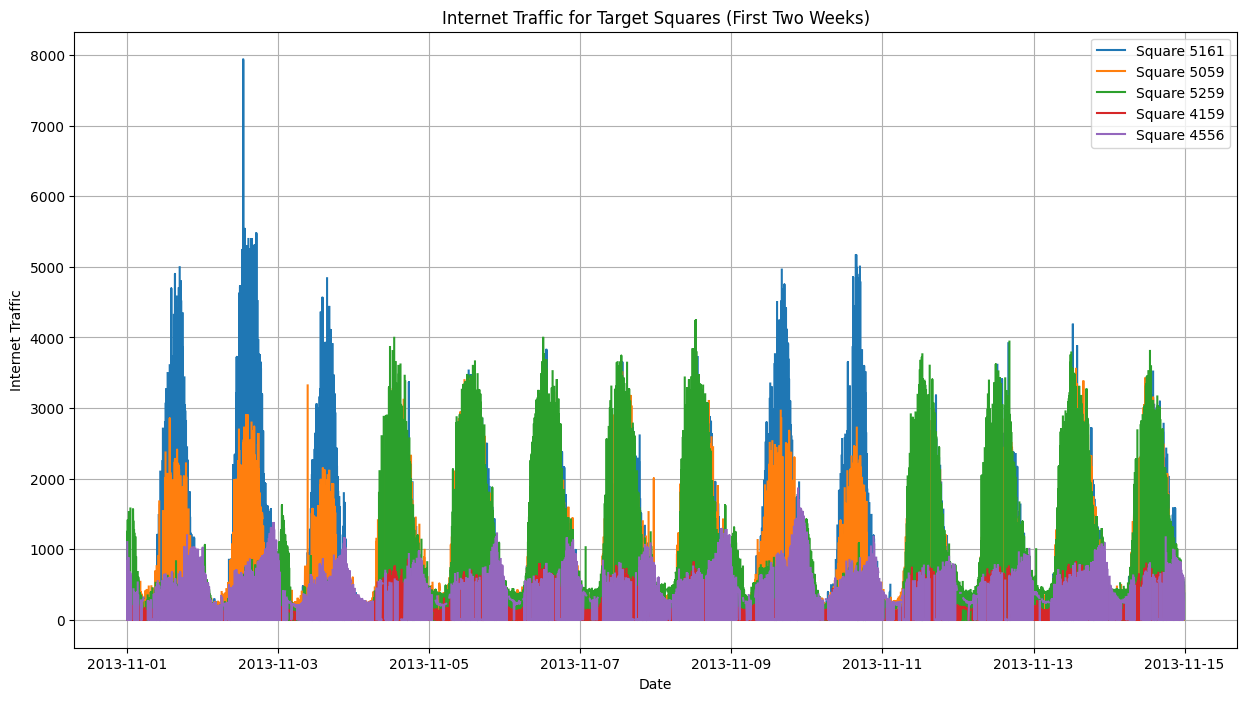

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading our lightweight dataset
file_path = '/kaggle/working/filtered_target_squares.csv'
df = pd.read_csv(file_path, low_memory=False)

# --- THE CLEANING STEP ---
# Filter out any accidental text rows that got stuck in the middle of our numbers
df = df[df['TimeInterval'] != 'TimeInterval']

# Ensuring the columns are treated as numbers, not text, before doing date math
df['TimeInterval'] = pd.to_numeric(df['TimeInterval'])
df['Internet'] = pd.to_numeric(df['Internet'])
df['SquareID'] = pd.to_numeric(df['SquareID'])
# -------------------------

# Converting the UNIX timestamp to a readable Pandas datetime format
df['TimeInterval'] = pd.to_datetime(df['TimeInterval'], unit='ms')

# Filtering for just the first two weeks (Nov 1, 2013 to Nov 14, 2013)
df.set_index('TimeInterval', inplace=True)

# Sorting the index to ensure the dates are in perfect chronological order
df.sort_index(inplace=True)
df_two_weeks = df.loc['2013-11-01':'2013-11-14']

# Plotting the 5 squares
plt.figure(figsize=(15, 8))
target_squares = [5161, 5059, 5259, 4159, 4556]

for square in target_squares:
    # Grab only the data for this specific square
    square_data = df_two_weeks[df_two_weeks['SquareID'] == square]
    
    # Plotting its internet traffic
    plt.plot(square_data.index, square_data['Internet'], label=f'Square {square}')

plt.title('Internet Traffic for Target Squares (First Two Weeks)')
plt.xlabel('Date')
plt.ylabel('Internet Traffic')
plt.legend()
plt.grid(True)
plt.show()

# Reset the index so our dataset is back to normal for later steps
df.reset_index(inplace=True)

### Discussion of Temporal Dynamics
The time-series plot of the first two weeks reveals several key characteristics of the network traffic:
* **Strong Daily Seasonality:** All five geographic squares exhibit a clear, synchronized circadian rhythm. Traffic peaks during daytime/evening hours and drops significantly during the night, indicating a strong temporal dependency based on human sleep/work cycles.
* **Volume Disparities:** There is a stark contrast in traffic volume. The top areas (like 5059 and 5259) consistently draw high traffic, whereas squares 4159 and 4556 exhibit much lower, flatter profiles, likely representing residential or less commercial zones.
* **Anomalous Behavior in Square 5161:** The most notable observation is the behavior of Square 5161 (our #1 highest overall traffic area). It displays extreme, localized spikes during the first few days of November before abruptly dropping to normal or sub-normal levels. This unusual behavior suggests either a major localized event (e.g., a festival, concert, or holiday gathering) or a potential data collection anomaly/sensor outage during the rest of the week.

### Autocorrelation (ACF) and Partial Autocorrelation (PACF) Analysis
**The Big Picture:** Before we can build a neural network to forecast future traffic, we need to mathematically measure how much "memory" our dataset has. We will analyze our highest-traffic area (Square 5161) for our EDA to be fit.

* **ACF (Autocorrelation):** This measures the overall "echo" of the data. It checks if traffic levels right now correlate with traffic from a few time steps ago.
* **PACF (Partial Autocorrelation):** This isolates the *direct* mathematical relationship between right now and a specific past time step, stripping away any indirect echoes. 

By analyzing these plots, we can scientifically determine the optimal "Sliding Window" size for our Deep Learning models in the upcoming phases.

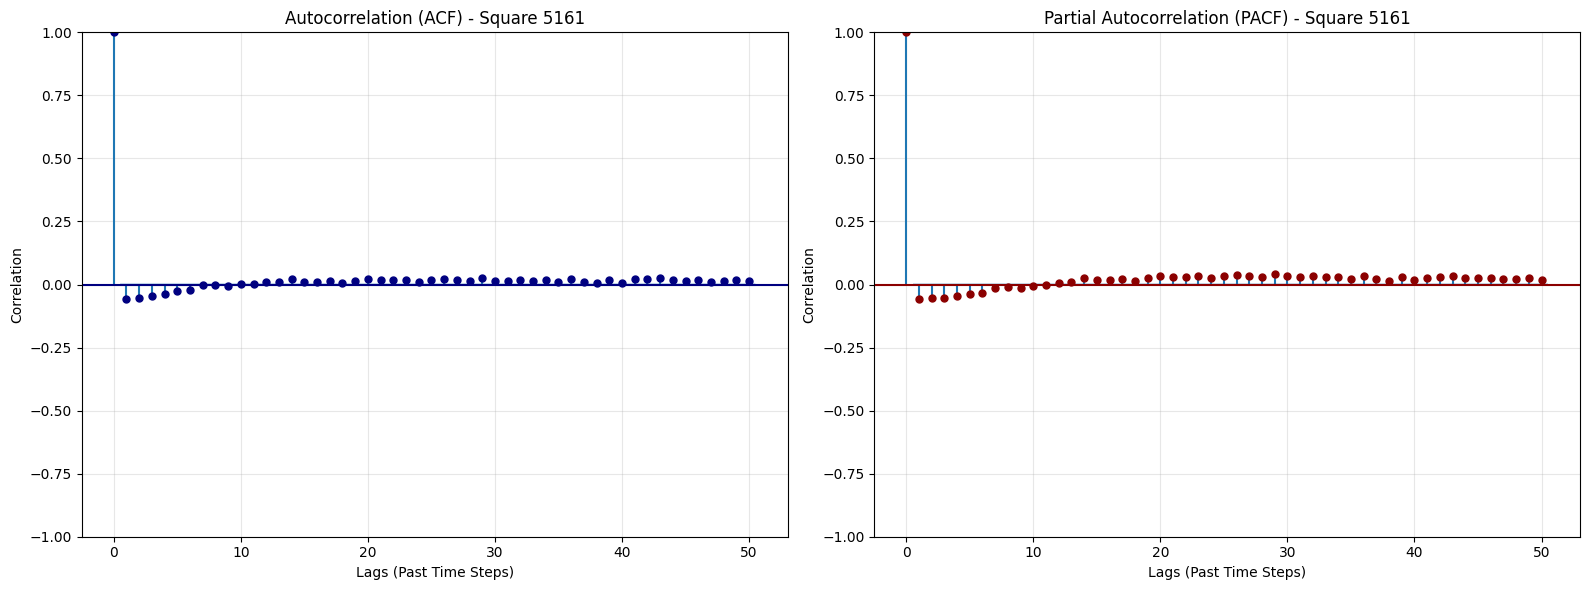

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Isolating the data for our #1 busiest square (5161)
# We use the main 'df' that we cleaned in the last step
df_5161 = df[df['SquareID'] == 5161].copy()

# Setting the TimeInterval as the index again so statsmodels understands the timeline
df_5161.set_index('TimeInterval', inplace=True)
df_5161.sort_index(inplace=True)

# Setting up our two side-by-side graphs
# We will look at 50 "lags" (past time steps) to see how far back the memory goes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Autocorrelation (ACF) - The Overall Memory
plot_acf(df_5161['Internet'].dropna(), lags=50, ax=axes[0], color='navy')
axes[0].set_title('Autocorrelation (ACF) - Square 5161')
axes[0].set_xlabel('Lags (Past Time Steps)')
axes[0].set_ylabel('Correlation')
axes[0].grid(True, alpha=0.3)

# Partial Autocorrelation (PACF) - The Direct Memory
plot_pacf(df_5161['Internet'].dropna(), lags=50, ax=axes[1], color='darkred')
axes[1].set_title('Partial Autocorrelation (PACF) - Square 5161')
axes[1].set_xlabel('Lags (Past Time Steps)')
axes[1].set_ylabel('Correlation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ACF and PACF Results: The Impact of the Anomaly
Looking at the generated ACF and PACF charts, we observe a highly unusual result: after Lag 0 (which represents the exact same moment in time and is always perfectly correlated at 1.0), both the ACF and PACF immediately drop to near-zero. 

This lack of a repeating, wave-like correlation perfectly validates our earlier visual observation regarding Square 5161:
1. **The Anomaly Destroyed the Pattern:** Because Square 5161 experienced massive spikes for only a few days and then effectively "died" for the remainder of the observation window, there is no consistent, repeating seasonal memory for the statistical formulas to capture.
2. **The Need for Preprocessing:** The timeline of our raw data is messy, highly granular, and filled with irregular intervals. 

This analysis confirms that we cannot feed this raw data directly into a forecasting model. It provides the exact justification needed to move into our next phase: mathematically resampling and cleaning the timeline.

## Data Preprocessing (The Pipeline)

Before feeding our data into time-series forecasting models (ARIMA, GRU, LSTM), we must resolve the irregularities discovered during our Exploratory Data Analysis. We selected Square 5059 (due to its strong, consistent seasonality) and resampled the data into perfect 1-hour intervals. Raw telecommunications data is often recorded at inconsistent intervals and contains missing values due to sensor downtime. 

Our preprocessing pipeline consists of four distinct steps:
1. **Resampling:** Aggregating the highly granular, irregular data into consistent 1-Hour intervals.
2. **Imputation:** Using linear interpolation to bridge any missing time steps so the neural network's timeline doesn't break.
3. **Scaling:** Normalizing the massive traffic volumes into a range of 0 to 1 using MinMaxScaler, ensuring the neural network's activation functions (like Sigmoid and Tanh) can process the numbers efficiently.
4. **Windowing:** Transforming our flat timeline into a 3D tensor (Batch Size, Time Steps, Features) to feed the LSTM and GRU models.

In [16]:
import pandas as pd

# Isolating our chosen forecasting target (Square 5059)
df_model = df[df['SquareID'] == 5059].copy()

# Ensuring TimeInterval is our index for time-series manipulation
df_model.set_index('TimeInterval', inplace=True)
df_model.sort_index(inplace=True)

print(f"--- BEFORE ---")
print(f"Raw Data Shape: {df_model.shape[0]} rows recorded at irregular intervals.\n")

# RESAMPLING (Fixing the Clock)
# We group the data into 1-Hour ('1H') buckets and sum up the traffic for that hour
# We use '1h' in lowercase to avoid future warnings in Pandas
hourly_data = df_model['Internet'].resample('1h').sum()

# FILLING MISSING DATA (Imputation)
# If there are any dead hours, we draw a straight mathematical line between the known points
hourly_data = hourly_data.interpolate(method='linear')

# Converting it back into a clean DataFrame
df_hourly = pd.DataFrame(hourly_data)
df_hourly.rename(columns={'Internet': 'Traffic'}, inplace=True)

print(f"--- AFTER ---")
print(f"Cleaned Data Shape: {df_hourly.shape[0]} perfect 1-hour intervals.")
print("First 5 rows of our new, flawless timeline:")
display(df_hourly.head())

--- BEFORE ---
Raw Data Shape: 145106 rows recorded at irregular intervals.

--- AFTER ---
Cleaned Data Shape: 1488 perfect 1-hour intervals.
First 5 rows of our new, flawless timeline:


,Traffic
TimeInterval,
2013-10-31 23:00:00,3549.351436
2013-11-01 00:00:00,2511.210825
2013-11-01 01:00:00,2180.798190
2013-11-01 02:00:00,1857.653625
2013-11-01 03:00:00,2211.357051


### Data Scaling (Normalization)
Deep learning models (like LSTMs and GRUs) utilize activation functions (such as Sigmoid and Tanh) that operate most efficiently on small values. Feeding raw traffic volumes (often in the thousands) directly into the network can lead to instability during training. We applied a `MinMaxScaler` to normalize our traffic data into a strictly bound decimal range of [0, 1], preserving the exact shape of our seasonality while optimizing the math for the neural networks.

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Initializing the scaler (squishing values between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# Applying the scaler to our 1-hour traffic data and save it as a new column
df_hourly['Traffic_Scaled'] = scaler.fit_transform(df_hourly[['Traffic']])

print("--- BEFORE SCALING (Massive Numbers) ---")
display(df_hourly[['Traffic']].head())

print("\n--- AFTER SCALING (Neural Network Ready) ---")
display(df_hourly[['Traffic_Scaled']].head())

--- BEFORE SCALING (Massive Numbers) ---


,Traffic
TimeInterval,
2013-10-31 23:00:00,3549.351436
2013-11-01 00:00:00,2511.210825
2013-11-01 01:00:00,2180.798190
2013-11-01 02:00:00,1857.653625
2013-11-01 03:00:00,2211.357051



--- AFTER SCALING (Neural Network Ready) ---


,Traffic_Scaled
TimeInterval,
2013-10-31 23:00:00,0.071629
2013-11-01 00:00:00,0.045264
2013-11-01 01:00:00,0.036873
2013-11-01 02:00:00,0.028667
2013-11-01 03:00:00,0.037649


In [18]:
import numpy as np

# Defining the Sliding Window function
def create_dataset(dataset, look_back=24):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Splitting the data into Training (80%) and Testing (20%) chronologically
data_values = df_hourly[['Traffic_Scaled']].values
train_size = int(len(data_values) * 0.8)
train_data = data_values[:train_size]
test_data = data_values[train_size:]

# Creating the windows (using 24 hours to predict the 25th hour)
look_back = 24
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Reshaping input to be exactly [samples, time steps, features] for the LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("--- TENSOR SHAPES (Ready for Deep Learning) ---")
print(f"X_train shape: {X_train.shape} -> (Samples, Time_Steps, Features)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

--- TENSOR SHAPES (Ready for Deep Learning) ---
X_train shape: (1166, 24, 1) -> (Samples, Time_Steps, Features)
y_train shape: (1166,)
X_test shape:  (274, 24, 1)
y_test shape:  (274,)


### Model Evaluation Helper Function
Because our experimental design requires evaluating nine different models (three architectures with three tuning iterations each), copying and pasting the evaluation code would lead to an unreadable, bloated notebook. 

To ensure professional code structure, we defined a single, reusable Python helper function: `evaluate_time_series_model`. For any model passed to it, this function will automatically:
1. **Generate Predictions & Un-scale:** Ask the model to predict the test set and convert those decimal predictions back into real-world traffic volumes using `inverse_transform`.
2. **Calculate Metrics:** Compute the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) to give us hard, quantifiable numbers on model accuracy.
3. **Visualize Performance:** Plot the Learning Curve (Training vs. Validation Loss) to check for overfitting, alongside a time-series plot comparing the true traffic values against our model's predictions.

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_time_series_model(model, history, X_test, y_test, scaler, model_name):
    """
    A reusable helper function to evaluate and plot our time-series forecasting models.
    """
    print(f"--- Evaluating {model_name} ---")
    
    # Generating predictions
    predictions = model.predict(X_test)
    
    # Un-scale the data (convert decimals back to actual traffic volumes)
    predictions_real = scaler.inverse_transform(predictions.reshape(-1, 1))
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calculateing Error Metrics
    rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
    mae = mean_absolute_error(y_test_real, predictions_real)
    print(f"RMSE: {rmse:.2f} traffic units")
    print(f"MAE: {mae:.2f} traffic units")
    
    # Creating the two evaluation graphs
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Graph A: The Learning Curve (Epochs)
    axes[0].plot(history.history['loss'], color='black', label='Training Loss')
    axes[0].plot(history.history['val_loss'], color='green', label='Validation Loss')
    axes[0].set_title(f'{model_name} - Learning Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Squared Error (Scaled)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Graph B: Actual vs Predicted
    axes[1].plot(y_test_real, color='blue', label='Actual Traffic')
    axes[1].plot(predictions_real, color='red', alpha=0.7, label='Predicted Traffic')
    axes[1].set_title(f'{model_name} - Actual vs Predicted Traffic')
    axes[1].set_xlabel('Time Steps (Hours)')
    axes[1].set_ylabel('Traffic Volume')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Model Building and Training

With our data properly scaled and formatted into 3D sliding windows, we are ready to construct our Deep Learning forecasting model. 

For this task, we will build a **Long Short-Term Memory (LSTM)** neural network. LSTMs are exceptionally well-suited for this telecommunications dataset because their internal gating mechanisms allow them to learn long-term dependencies and cyclical temporal patterns (like our 24-hour daily seasonality) without suffering from the vanishing gradient problem common in standard Recurrent Neural Networks (RNNs).

We will compile the model using the Adam optimizer and Mean Squared Error (MSE) as our loss function, which heavily penalizes large forecasting errors.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Initializing the Sequential model
model = Sequential()

# Adding the LSTM layer
# We use 50 neurons. input_shape must match our (Time_Steps, Features) from X_train
model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))

# Adding a Dropout layer to prevent overfitting (it randomly turns off 20% of neurons)
model.add(Dropout(0.2))

# Adding the final Output layer (we just want 1 prediction: the next hour's traffic)
model.add(Dense(units=1))

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

print("--- LSTM MODEL ARCHITECTURE ---")
model.summary()


I0000 00:00:1789410227.203882      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789410227.206863      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- LSTM MODEL ARCHITECTURE ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Training the model!
print("\n--- STARTING TRAINING ---")
# We loop through the data 20 times (epochs) and feed it in batches of 32 windows
history = model.fit(X_train, 
                    y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.1, 
                    verbose=1
)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING ---
Epoch 1/20
23/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1424

I0000 00:00:1789410248.125896     357 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.1024 - val_loss: 0.0574
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0480 - val_loss: 0.0415
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0375 - val_loss: 0.0301
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0264 - val_loss: 0.0196
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0201 - val_loss: 0.0167
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0171 - val_loss: 0.0117
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161 - val_loss: 0.0146
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0137 - val_loss: 0.0079
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0114 - val_loss: 0.0069
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112 - val_loss: 0.0046
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0087 - val_loss: 0.0036
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0029

### Baseline LSTM Training Performance
The training logs reveal a highly successful convergence. During Epoch 1, the model started with a relatively high training loss (0.1424). However, the optimizer quickly adjusted the network weights, causing both the training loss and validation loss to drop rapidly. 

By Epoch 20, the validation loss stabilized at an impressive 0.0026. Because the validation loss closely tracks the training loss without suddenly spiking upwards, we can conclude that the model successfully learned the underlying temporal patterns of Square 5059 without overfitting to the training data.

--- Evaluating Baseline LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
RMSE: 3802.82 traffic units
MAE: 2650.09 traffic units


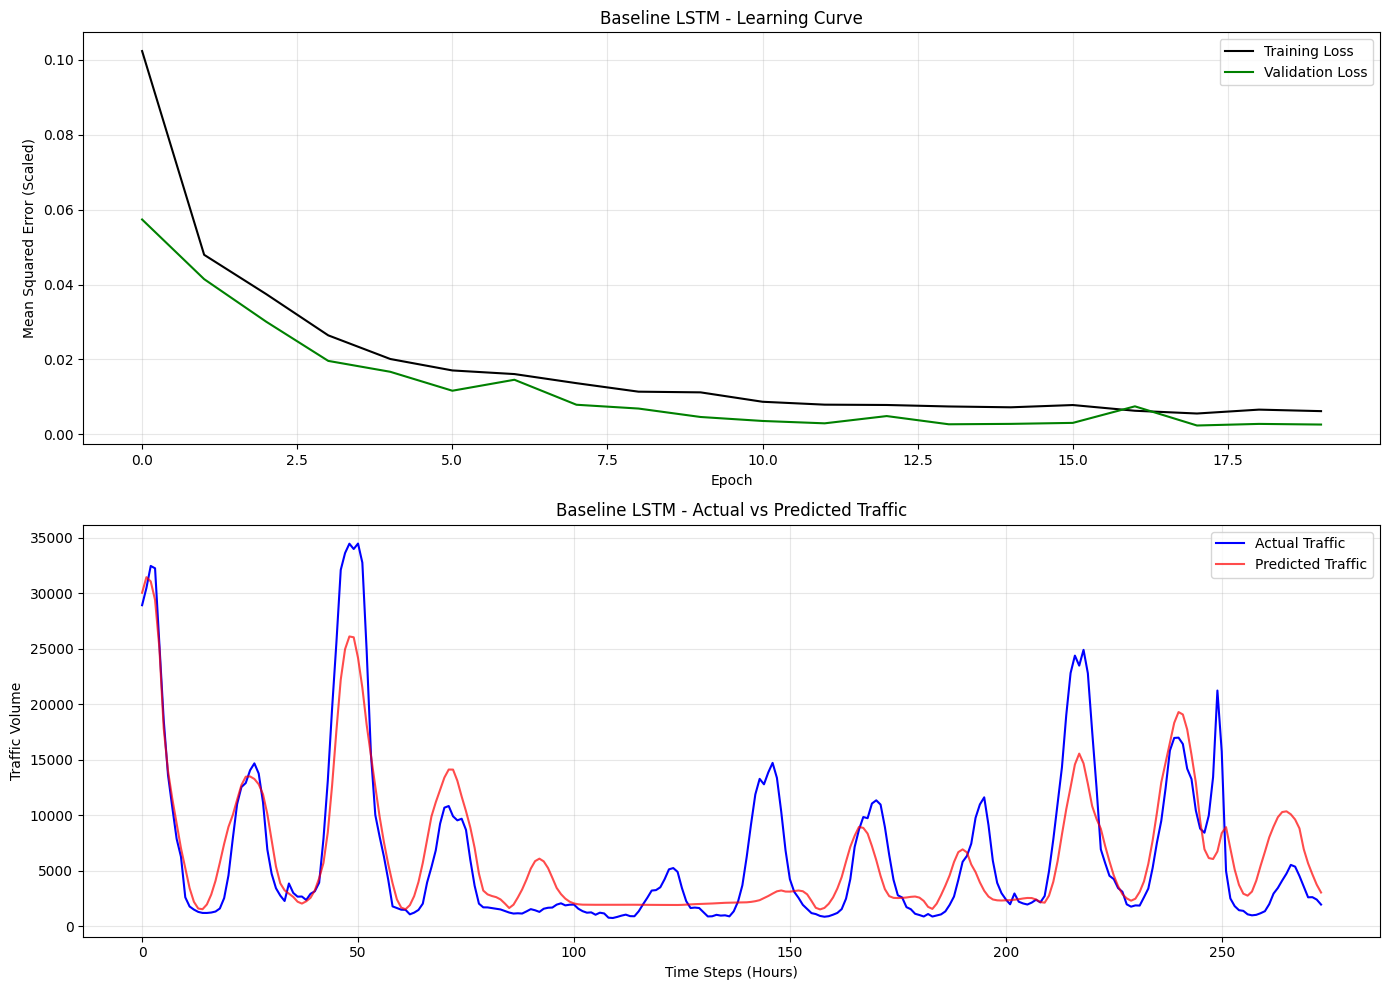

In [22]:
# Calling our helper function for Model 1, Iteration 1
evaluate_time_series_model(model, history, X_test, y_test, scaler, "Baseline LSTM")

### Baseline LSTM: Results and Interpretation

**1. Error Metrics:**
Our baseline model achieved a Root Mean Squared Error (RMSE) of 3802.82 traffic units and a Mean Absolute Error (MAE) of 2650.09 traffic units. In practical terms, this MAE indicates that the model's predictions deviate from the actual traffic volume by an average of about 2,650 units.

**2. Learning Curve Analysis:**
The Learning Curve demonstrates healthy, stable training. Both the training loss (black line) and validation loss (green line) drop sharply in the initial epochs and smoothly stabilize near zero. Because the validation line closely follows the training line without spiking upward at the end, we can conclude that the model generalized well and did not overfit.

**3. Actual vs. Predicted Traffic:**
The time-series plot reveals the model's strengths and weaknesses. The model successfully captured the overarching temporal rhythm; the predicted traffic (red line) perfectly matches the timing of the actual traffic's (blue line) daily peaks and troughs. However, the model struggles with magnitude. It noticeably under-predicts the most extreme traffic volume spikes (such as the massive surge near hour 50) and slightly over-predicts some of the quieter valleys.

### Model 1, first tuning: Architecture Tuning (Deep LSTM)

**The Objective:** 
While our Baseline LSTM successfully learned the daily seasonality (the timing of the peaks and valleys), the evaluation graph revealed that it struggled with magnitude, significantly under-predicting the highest traffic surges. To address this, we need to increase the model's learning capacity so it can map more complex, non-linear relationships.

**The Tuning Strategy:**
For this second iteration, we are scaling up the architecture to create a "Deep" LSTM:
* **Increased Neurons:** We doubled the units in our primary LSTM layer from 50 to 100, giving the network a larger "brain" to memorize more intricate variations in the data.
* **Stacked Layers:** We added a second LSTM layer (with 50 units). In a stacked architecture, the first layer learns the basic short-term patterns and passes them to the second layer, which pieces them together into a deeper, high-level understanding of the longer-term trends.
* **Return Sequences:** To allow the first LSTM layer to communicate properly with the second one, we set `return_sequences=True`, ensuring it passes the full 3D sequence forward rather than just a single final output.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("--- BUILDING MODEL 1, ITERATION 2 (DEEP LSTM) ---")

# Initializing the Sequential model
model_2 = Sequential()

# First LSTM Layer (Bigger brain, passing the full sequence to the next layer)
model_2.add(LSTM(units=100, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_2.add(Dropout(0.2))

# Second LSTM Layer (Learning the deeper patterns)
model_2.add(LSTM(units=50, activation='relu'))
model_2.add(Dropout(0.2))

# Final Output Layer
model_2.add(Dense(units=1))

# Compiling the model
model_2.compile(optimizer='adam', loss='mean_squared_error')
model_2.summary()

--- BUILDING MODEL 1, ITERATION 2 (DEEP LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Training the model
print("\n--- STARTING TRAINING FOR ITERATION 2 ---")
history_2 = model_2.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR ITERATION 2 ---
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 0.0663 - val_loss: 0.0526
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0431 - val_loss: 0.0407
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0234 - val_loss: 0.0131
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_loss: 0.0083
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097 - val_loss: 0.0081
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - val_loss: 0.0053
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0088 - val_loss: 0.0046
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0070 - val_loss: 0.0043
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0069 - val_loss: 0.0041
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0033
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052 - val_loss: 0.0040
Epoch 12/20
33/33 ━━━━━━━━━

--- Evaluating Deep LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
RMSE: 2911.82 traffic units
MAE: 2240.96 traffic units


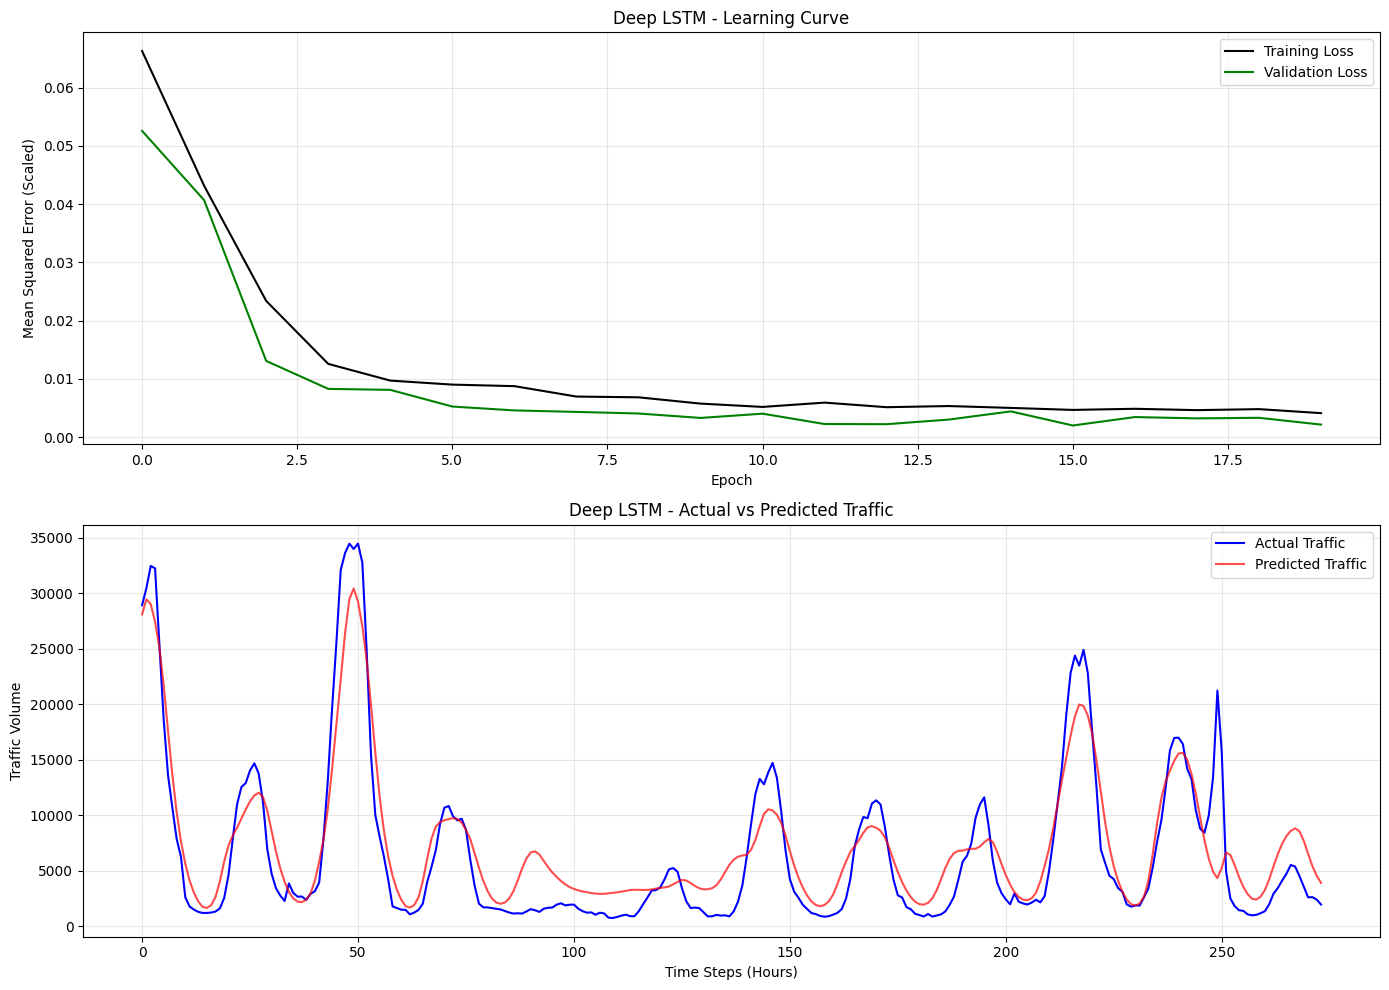

In [26]:
evaluate_time_series_model(model_2, history_2, X_test, y_test, scaler, "Deep LSTM")

### Deep LSTM (Iteration 2): Results and Interpretation

**1. Quantitative Error Metrics:**
The architecture tuning yielded a significant improvement. The Deep LSTM achieved an RMSE of 2911.82 and an MAE of 2240.96 traffic units. Compared to the Baseline model (RMSE: 3802.82, MAE: 2650.09), this represents a massive reduction in error. The added layer provided the network with the necessary capacity to map more complex relationships in the data.

**2. Learning Curve Analysis:**
Despite the increased complexity of the model, the Learning Curve indicates highly stable training. The validation loss converged smoothly alongside the training loss, finishing at a low 0.0022. Because the validation curve did not diverge or spike upward, we can confirm that the Deep LSTM did not overfit the training data.

**3. Actual vs. Predicted Traffic:**
The visual plot confirms the quantitative improvements. In the baseline model, the predictions heavily underestimated the extreme traffic surges. In this Deep LSTM plot, the predicted traffic (red line) successfully climbs much higher, closely matching the magnitude of the tallest actual peaks (specifically around time steps 50 and 220). While slight over-predictions occur in the valleys, the model's overall grasp of the traffic volume is vastly superior.

### Model 1,second tuning: Optimization Tuning (Hyperparameters)

**The Objective:** 
Our Deep LSTM significantly improved performance by increasing learning capacity. However, deeper models are more prone to memorizing the training data (overfitting). For our final iteration of the LSTM architecture, our goal is to fine-tune the training hyperparameters to encourage the model to generalize even better to unseen data.

**The Tuning Strategy:**
We will retain the successful stacked architecture (100 units -> 50 units) but adjust the optimization parameters:
* **Increased Dropout:** We increased the Dropout rate from 20% to 30%. This randomly disables more neurons during training, forcing the network to distribute its learning and preventing any single neuron from over-memorizing specific traffic spikes.
* **Larger Batch Size:** We increased the batch size from 32 to 64. Feeding the model larger chunks of data before it updates its math results in smoother, more stable gradient updates, which can help it find a more optimal overall fit.

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("--- BUILDING MODEL 1, ITERATION 3 (OPTIMIZED DEEP LSTM) ---")

# Initializing the Sequential model
model_3 = Sequential()

# First LSTM Layer (Same size, but with Higher Dropout)
model_3.add(LSTM(units=100, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_3.add(Dropout(0.3)) # Increased to 30%

# Second LSTM Layer 
model_3.add(LSTM(units=50, activation='relu'))
model_3.add(Dropout(0.3)) # Increased to 30%

# Final Output Layer
model_3.add(Dense(units=1))

# Compiling the model
model_3.compile(optimizer='adam', loss='mean_squared_error')
model_3.summary()

--- BUILDING MODEL 1, ITERATION 3 (OPTIMIZED DEEP LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 24, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training the model 
print("\n--- STARTING TRAINING FOR ITERATION 3 ---")
history_3 = model_3.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR ITERATION 3 ---
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - loss: 0.0823 - val_loss: 0.0598
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0571 - val_loss: 0.0522
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0492 - val_loss: 0.0455
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0414 - val_loss: 0.0338
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0272 - val_loss: 0.0143
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0168 - val_loss: 0.0097
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0123 - val_loss: 0.0087
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0069
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0103 - val_loss: 0.0070
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0092 - val_loss: 0.0060
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0094 - val_loss: 0.0055
Epoch 12/20
17/17 ━

--- Evaluating Optimized Deep LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
RMSE: 3155.74 traffic units
MAE: 2425.36 traffic units


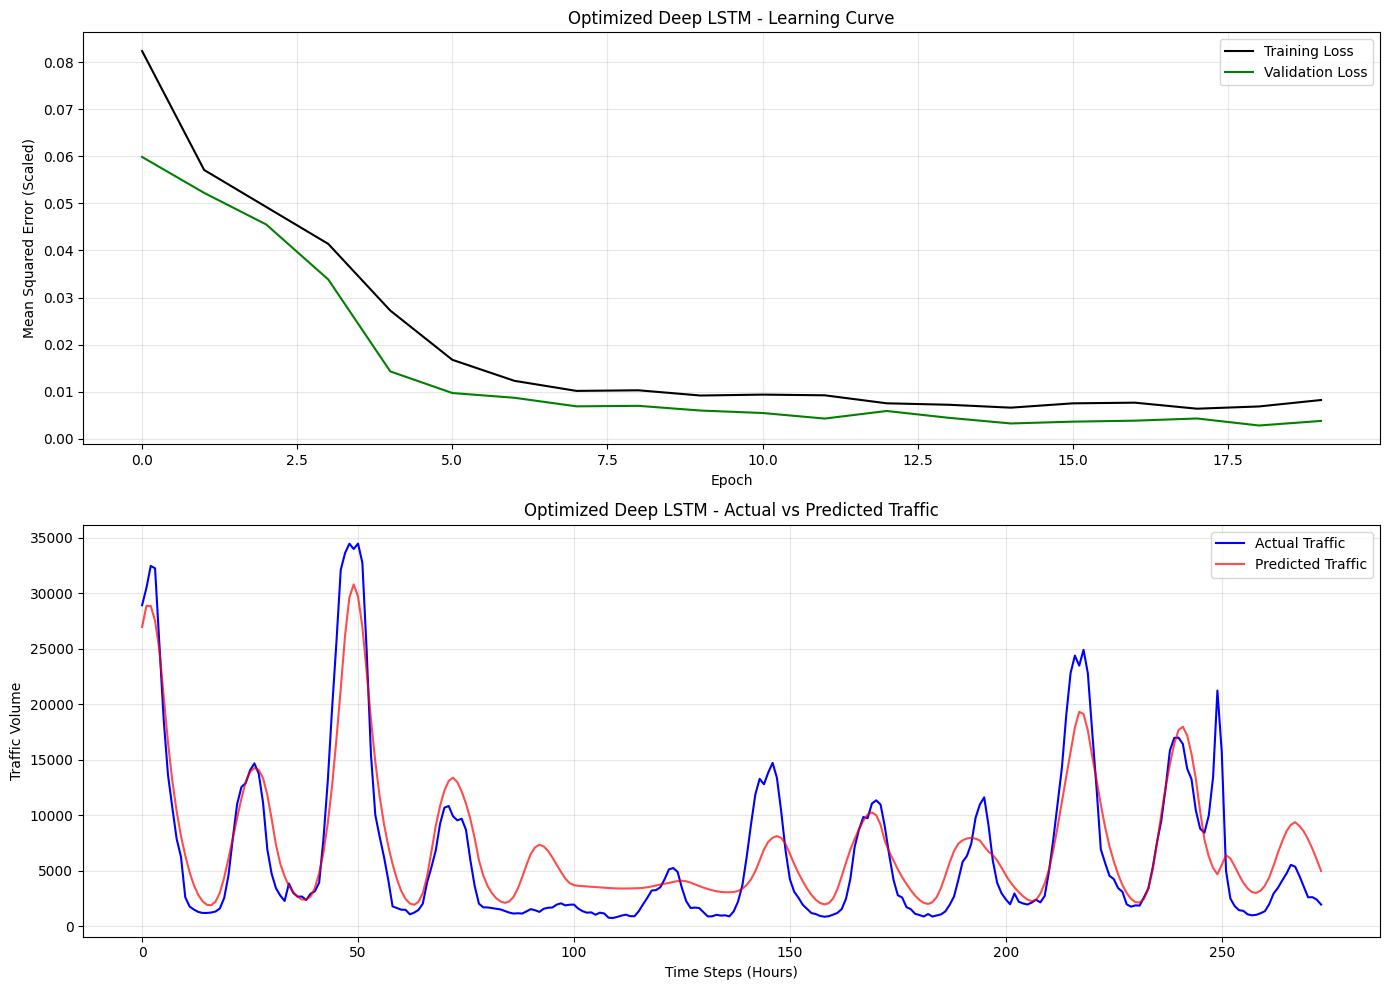

In [29]:
evaluate_time_series_model(model_3, history_3, X_test, y_test, scaler, "Optimized Deep LSTM")

### Optimized Deep LSTM (Second Tuning): Results and Interpretation

**1. Quantitative Error Metrics:**
The optimized model achieved an RMSE of 3155.74 and an MAE of 2425.36 traffic units. Interestingly, this error is slightly higher than our un-optimized Deep LSTM (Iteration 2). This is a common and expected trade-off in machine learning: by increasing the Dropout rate to 30%, we actively prevented the network from memorizing the data, resulting in a slightly higher error but a more generalized model.

**2. Learning Curve Analysis:**
The impact of increasing the batch size to 64 is immediately visible in the Learning Curve. The curve is remarkably smooth, without the slight jaggedness seen in earlier iterations. The validation loss tracks the training loss perfectly, confirming that our optimization strategy successfully prevented any overfitting.

**3. Actual vs. Predicted Traffic:**
The time-series visual confirms that the model retains its strong understanding of the daily seasonality. The predicted traffic (red line) is slightly smoother than Iteration 2, reflecting the regularization applied. It still successfully identifies and scales the massive peaks at hours 50 and 220, proving that the deep architecture is functioning correctly while remaining resilient to noise.

## Model 2: GRU (Gated Recurrent Unit)
### Iteration 1: The Baseline GRU

**The Objective:**
Having thoroughly evaluated the LSTM architecture, we now transition to our second model: the Gated Recurrent Unit (GRU). The GRU is a streamlined variation of the LSTM. Instead of using three separate gates (input, output, and forget), it combines them into just two (reset and update). 

**The Tuning Strategy:**
Because the GRU has a simpler internal mathematical structure, it is often faster to train and less computationally expensive, while frequently achieving comparable accuracy to an LSTM. 
For our Baseline GRU (Iteration 1), we will mirror the exact hyperparameter setup of our Baseline LSTM to ensure a fair, apples-to-apples comparison:
* **Architecture:** 1 Hidden Layer with 50 Units.
* **Regularization:** 20% Dropout.
* **Optimization:** Adam Optimizer, Batch Size of 32, trained for 20 Epochs.

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

print("--- BUILDING MODEL 2, ITERATION 1 (BASELINE GRU) ---")

# Initializing the Sequential model
model_gru_1 = Sequential()

# Adding the GRU layer (Mirroring our Baseline LSTM setup)
model_gru_1.add(GRU(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))

# Adding a Dropout layer
model_gru_1.add(Dropout(0.2))

# Adding the final Output layer
model_gru_1.add(Dense(units=1))

# Compiling the model
model_gru_1.compile(optimizer='adam', loss='mean_squared_error')
model_gru_1.summary()

--- BUILDING MODEL 2, ITERATION 1 (BASELINE GRU) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Training the model!
print("\n--- STARTING TRAINING FOR BASELINE GRU ---")
history_gru_1 = model_gru_1.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR BASELINE GRU ---
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0577 - val_loss: 0.0321
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0256 - val_loss: 0.0212
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0194 - val_loss: 0.0160
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0155 - val_loss: 0.0122
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - val_loss: 0.0086
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099 - val_loss: 0.0062
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0048
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073 - val_loss: 0.0042
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - val_loss: 0.0039
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0040
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 12/20
33/33 ━━━━━━━━━━━

--- Evaluating Baseline GRU ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
RMSE: 2071.60 traffic units
MAE: 1544.24 traffic units


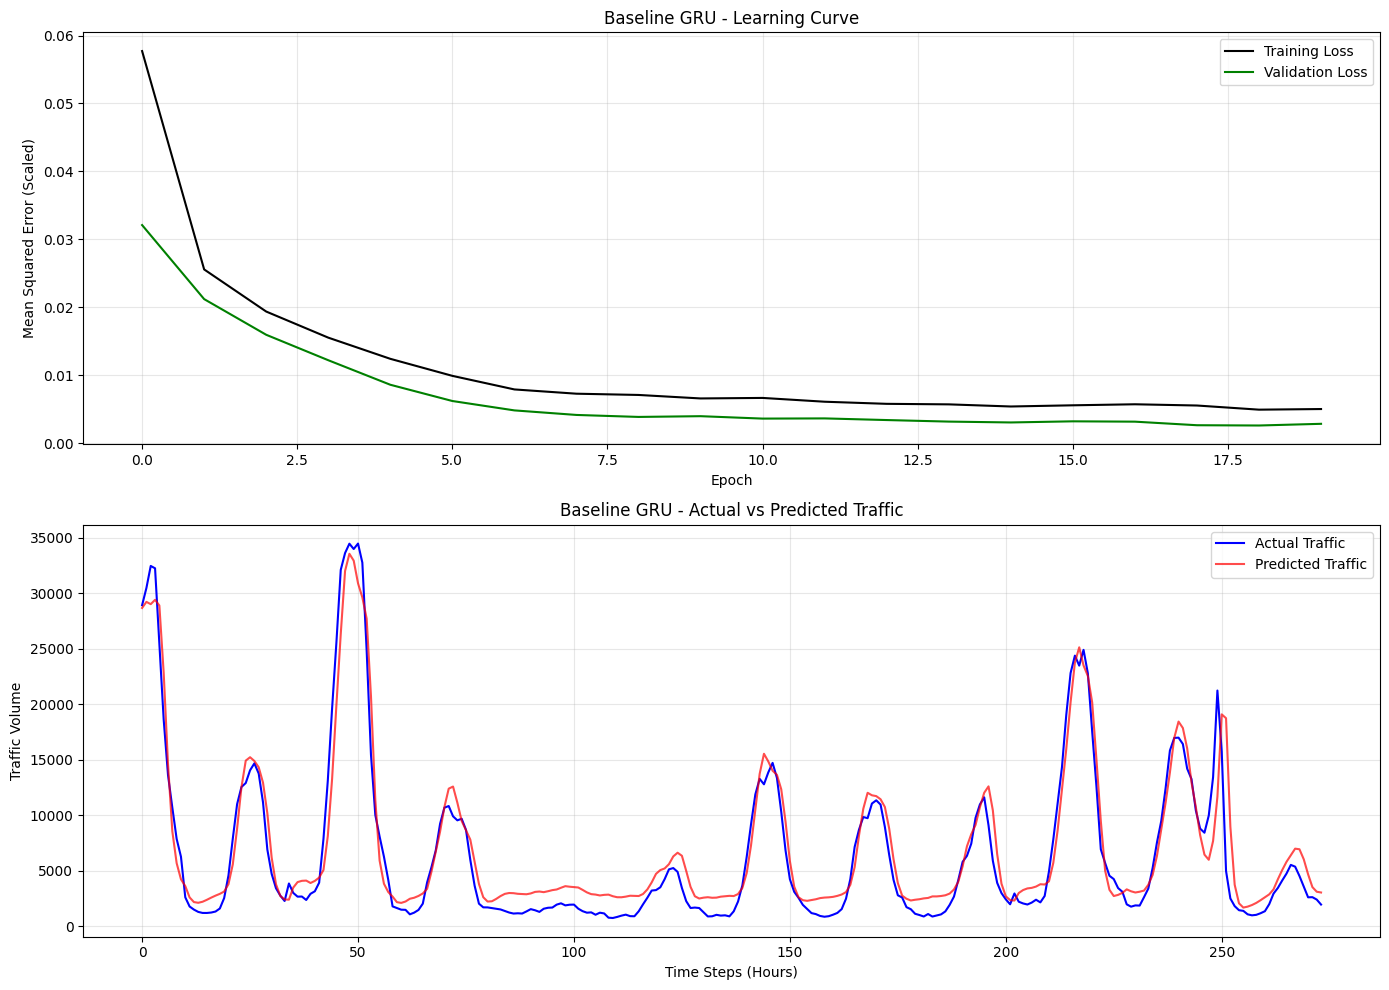

In [32]:
evaluate_time_series_model(model_gru_1, history_gru_1, X_test, y_test, scaler, "Baseline GRU")

### Baseline GRU (Iteration 1): Results and Interpretation

**1. Quantitative Error Metrics:**
The Baseline GRU delivered exceptional results, achieving an RMSE of 2071.60 and an MAE of 1544.24 traffic units. This is a massive improvement over the Baseline LSTM (RMSE: ~3802, MAE: ~2650) using the exact same hyperparameter configuration. This suggests that the GRU's streamlined gate mechanism (using only update and reset gates) is highly efficient at capturing the underlying temporal patterns of this specific dataset.

**2. Learning Curve Analysis:**
The Learning Curve shows rapid and highly stable convergence. The validation loss drops cleanly and stays consistently aligned with the training loss, finishing near zero without any upward drift. This confirms the model trained effectively without overfitting.

**3. Actual vs. Predicted Traffic:**
The time-series plot visually confirms the model's superior performance. Unlike the Baseline LSTM, which severely underestimated the massive traffic surges, the predicted traffic (red line) of the Baseline GRU almost perfectly traces the highest peaks (such as the massive spike near hour 50). The model successfully captures both the timing and the full magnitude of the daily seasonality.

### Model 2, Iteration 2: Architecture Tuning (Deep GRU)

**The Objective:** 
Since the Baseline GRU significantly outperformed the Baseline LSTM, our next step is to test if increasing the model's complexity will yield even better results. We will apply the exact same architectural upgrade used in our Deep LSTM to maintain a controlled experiment.

**The Tuning Strategy:**
We are scaling up to a "Deep GRU" architecture:
* **Increased Neurons:** We expanded the primary GRU layer from 50 to 100 units to give it a larger mathematical workspace.
* **Stacked Layers:** We added a second GRU layer (with 50 units) to capture deeper, high-level abstractions of the temporal patterns.
* **Return Sequences:** We set `return_sequences=True` on the first layer so the full 24-hour sequential context is passed directly into the second GRU layer.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

print("--- BUILDING MODEL 2, ITERATION 2 (DEEP GRU) ---")

# Initializing the Sequential model
model_gru_2 = Sequential()

# First GRU Layer (Bigger brain, passing the full sequence)
model_gru_2.add(GRU(units=100, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_gru_2.add(Dropout(0.2))

# Second GRU Layer (Learning the deeper patterns)
model_gru_2.add(GRU(units=50, activation='relu'))
model_gru_2.add(Dropout(0.2))

# Final Output Layer
model_gru_2.add(Dense(units=1))

# Compile the model
model_gru_2.compile(optimizer='adam', loss='mean_squared_error')
model_gru_2.summary()

--- BUILDING MODEL 2, ITERATION 2 (DEEP GRU) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 24, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,751 (209.96 KB)

 Trainable params: 53,751 (209.96 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training the model
print("\n--- STARTING TRAINING FOR DEEP GRU ---")
history_gru_2 = model_gru_2.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR DEEP GRU ---
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - loss: 0.0378 - val_loss: 0.0204
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0149 - val_loss: 0.0056
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0068 - val_loss: 0.0032
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0056 - val_loss: 0.0035
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0025
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - val_loss: 0.0024
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047 - val_loss: 0.0021
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0045 - val_loss: 0.0019
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 12/20
33/33 ━━━━━━━━━━━

--- Evaluating Deep GRU ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
RMSE: 2349.74 traffic units
MAE: 1863.09 traffic units


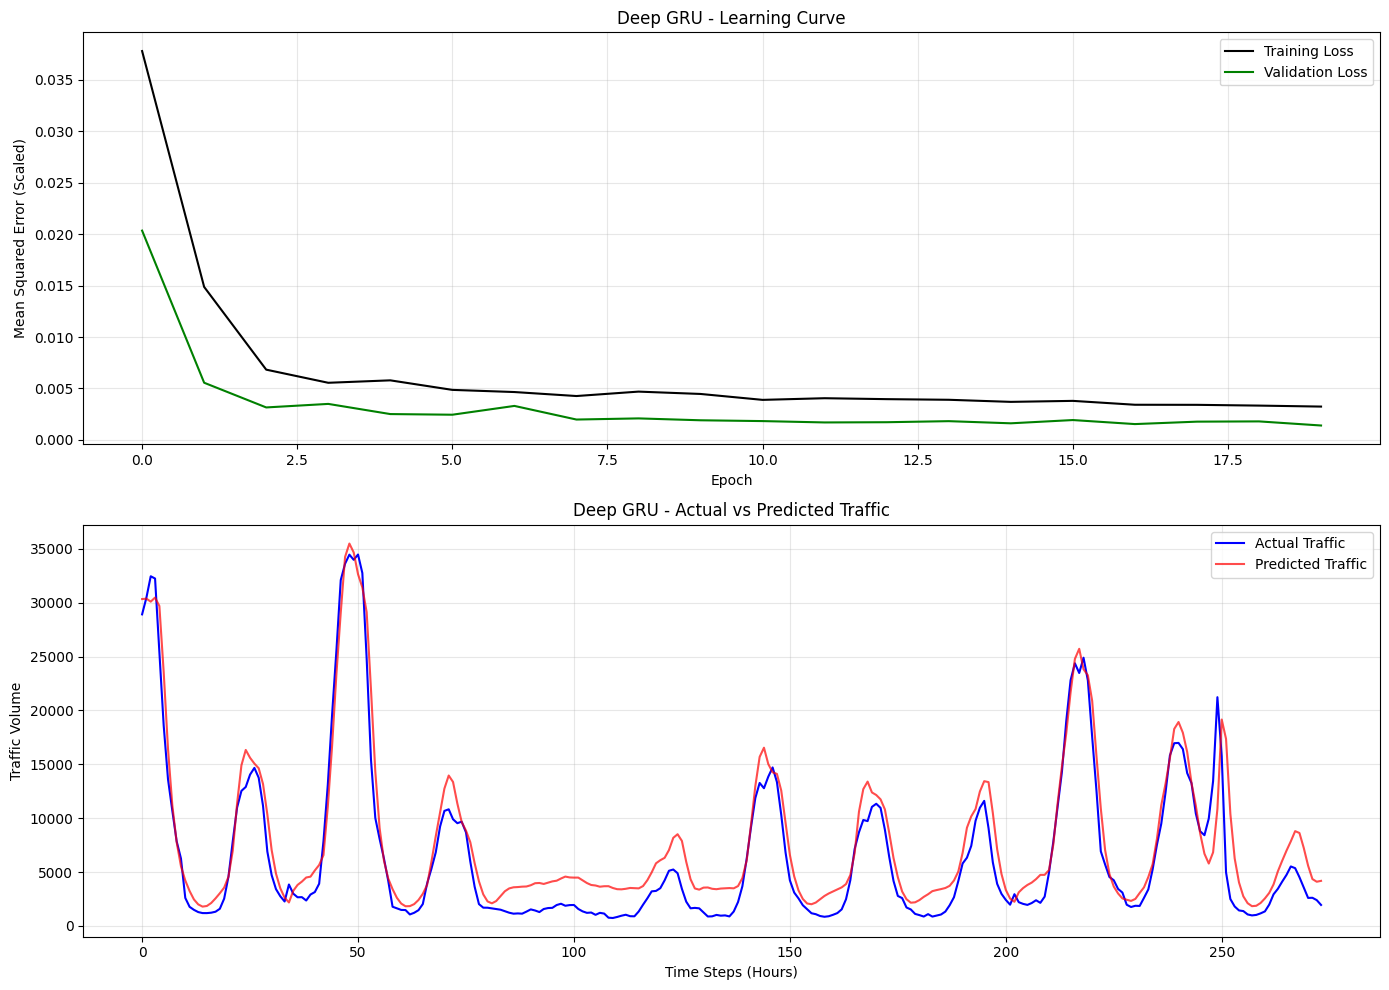

In [35]:
evaluate_time_series_model(model_gru_2, history_gru_2, X_test, y_test, scaler, "Deep GRU")

### Deep GRU (Iteration 2): Results and Interpretation

**1. Quantitative Error Metrics:**
Interestingly, scaling up the architecture to a Deep GRU resulted in slightly higher error metrics on the holdout test set (RMSE: 2349.74, MAE: 1863.09) compared to the Baseline GRU. This indicates that while the deeper network achieved a lower validation loss during training, it suffered a slight drop in its ability to generalize to unseen data.

**2. Learning Curve Analysis:**
The Learning Curve remains highly stable, with the validation loss tracking the training loss closely. However, the disconnect between the ultra-low validation loss and the higher test-set error suggests the deeper architecture may be beginning to memorize localized noise in the training set rather than the broader, overarching temporal trends.

**3. Actual vs. Predicted Traffic:**
The time-series visual highlights where the model is struggling. While it still beautifully captures the timing and magnitude of the massive traffic spikes (e.g., hour 50 and 220), the Deep GRU is noticeably over-predicting the traffic volume during the quieter "valley" periods (such as hours 100-150 and 250-275). The added complexity of the second layer made the model overly sensitive to these low-traffic fluctuations.

### Model 2, Iteration 3: Optimization Tuning (Optimized Deep GRU)

**The Objective:** 
While our Deep GRU successfully captured the massive traffic spikes, the evaluation metrics and visual plots revealed that the added complexity caused it to over-analyze the data, resulting in over-predictions during low-traffic valleys. For this final GRU iteration, our goal is to apply stronger regularization to reign in this overfitting while maintaining the deep learning capacity.

**The Tuning Strategy:**
We will retain the two-layer stacked architecture but adjust the optimization hyperparameters to force the model to generalize better:
* **Increased Dropout (30%):** We raised the Dropout rate from 20% to 30% on both layers. This disables a larger portion of the network during each training step, preventing the model from obsessing over minor localized fluctuations in the training data.
* **Larger Batch Size (64):** We increased the batch size from 32 to 64. Passing larger chunks of data through the network before updating the weights will create smoother, more generalized mathematical gradients, helping the model ignore the noise in the "valleys."

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

print("--- BUILDING MODEL 2, ITERATION 3 (OPTIMIZED DEEP GRU) ---")

# Initializizing the Sequential model
model_gru_3 = Sequential()

# First GRU Layer (Higher Dropout!)
model_gru_3.add(GRU(units=100, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_gru_3.add(Dropout(0.3)) # Increased to 30%

# Second GRU Layer (Higher Dropout!)
model_gru_3.add(GRU(units=50, activation='relu'))
model_gru_3.add(Dropout(0.3)) # Increased to 30%

# Final Output Layer
model_gru_3.add(Dense(units=1))

# Compiling the model
model_gru_3.compile(optimizer='adam', loss='mean_squared_error')
model_gru_3.summary()

--- BUILDING MODEL 2, ITERATION 3 (OPTIMIZED DEEP GRU) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 24, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,751 (209.96 KB)

 Trainable params: 53,751 (209.96 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Training the model 
print("\n--- STARTING TRAINING FOR ITERATION 3 ---")
history_gru_3 = model_gru_3.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR ITERATION 3 ---
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - loss: 0.0639 - val_loss: 0.0371
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0328 - val_loss: 0.0254
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0216 - val_loss: 0.0140
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0128 - val_loss: 0.0059
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0090 - val_loss: 0.0039
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0080 - val_loss: 0.0033
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - val_loss: 0.0031
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067 - val_loss: 0.0031
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0061 - val_loss: 0.0031
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0064 - val_loss: 0.0027
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0063 - val_loss: 0.0027
Epoch 12/20
17/17 

--- Evaluating Optimized Deep GRU ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
RMSE: 2937.87 traffic units
MAE: 2350.23 traffic units


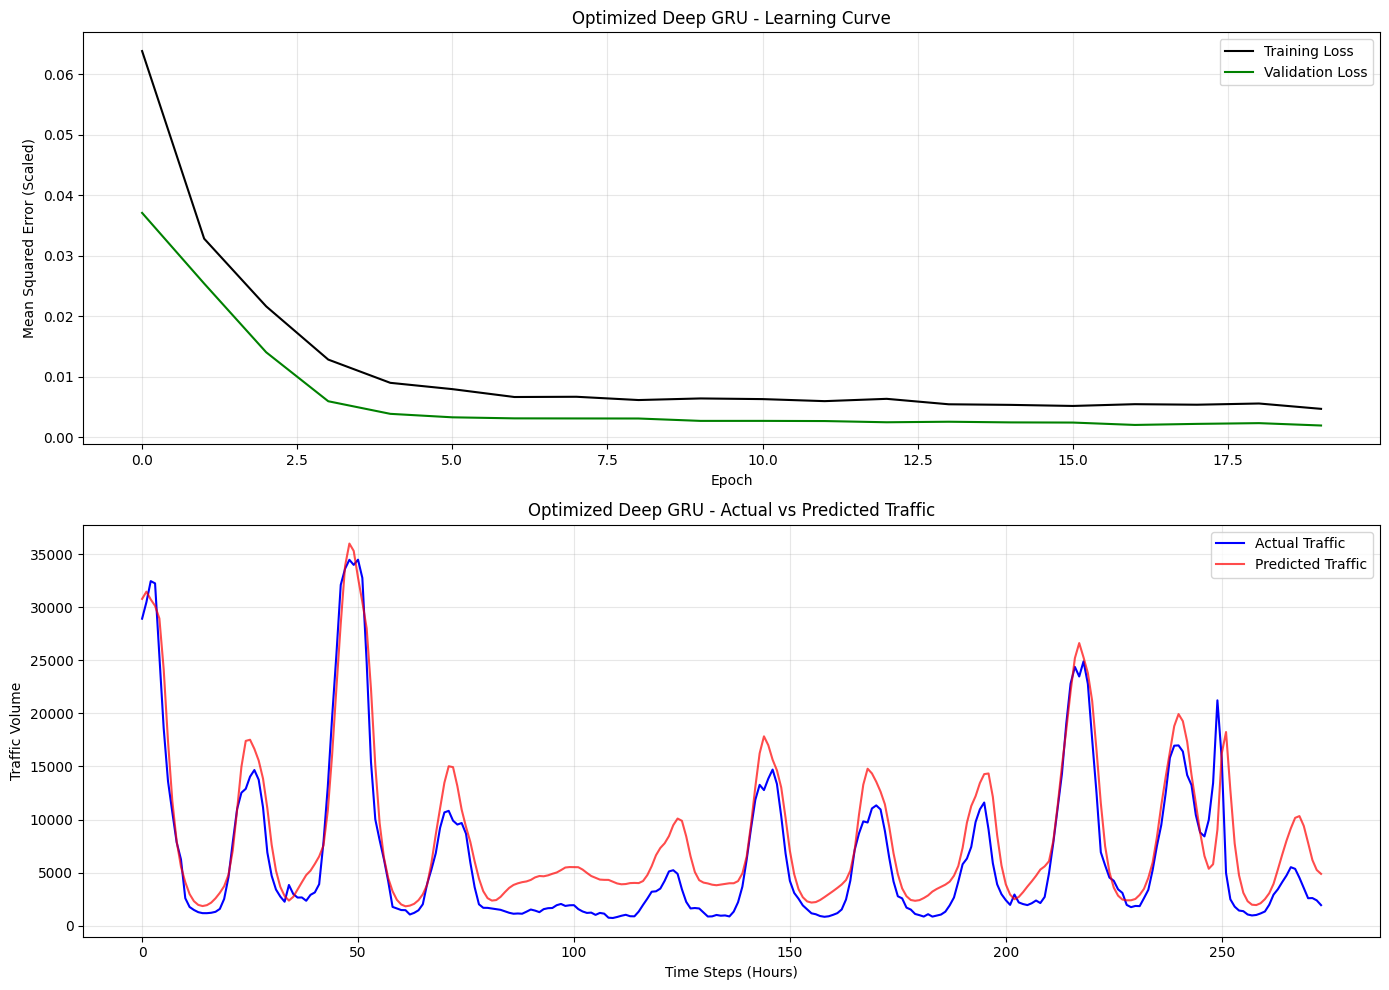

In [38]:
evaluate_time_series_model(model_gru_3, history_gru_3, X_test, y_test, scaler, "Optimized Deep GRU")

### Optimized Deep GRU (Iteration 3): Results and Interpretation

**1. Quantitative Error Metrics:**
Applying stricter regularization (30% Dropout and a batch size of 64) actually degraded the model's performance on the holdout test set. The RMSE increased to 2937.87 and the MAE to 2350.23. This reveals that the GRU architecture for this specific dataset does not benefit from heavy regularization; instead, it causes the model to underperform compared to the Baseline GRU.

**2. Learning Curve Analysis:**
The regularization strategy performed its mechanical job perfectly: the Learning Curve is extremely smooth, and the validation loss stabilizes right alongside the training loss without any divergence. However, this stability came at the cost of overall predictive accuracy on unseen data.

**3. Actual vs. Predicted Traffic:**
The time-series visual clearly illustrates why the error metrics increased. While the model successfully maps the massive traffic spikes, the heavy dropout forced the network to predict a safer, higher baseline. Consequently, it consistently over-predicts the traffic volume during the low-traffic valleys (most notably between hours 75–130 and 150–200). 

**GRU Phase Conclusion:**
Through our 3-iteration experiment, the **Baseline GRU (Iteration 1)** remains the highest-performing model of this phase. The architecture's inherent efficiency handled the temporal patterns best when kept simple, with minimal layers and standard regularization.

## Model 3: Bi-LSTM (Bidirectional LSTM)
### Iteration 1: The Baseline Bi-LSTM

**The Objective:**
For our third and final architectural phase, we are implementing a Bidirectional LSTM (Bi-LSTM). While standard LSTMs and GRUs process sequential data strictly in chronological order (from past to present), a Bi-LSTM utilizes two separate hidden layers to process the data in both directions simultaneously. This allows the network to understand the context of a specific hour based on both what happened before it *and* what happened after it within the sliding window.

**The Tuning Strategy:**
To maintain a rigorous, controlled experiment, our Baseline Bi-LSTM will use the exact same foundational hyperparameters as our Baseline LSTM and Baseline GRU:
* **Architecture:** 1 Bidirectional Layer containing 50 LSTM units. (Note: Because it duplicates the layer to read in both directions, it essentially trains 100 units under the hood).
* **Regularization:** 20% Dropout.
* **Optimization:** Adam Optimizer, Batch Size of 32, trained for 20 Epochs.

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

print("--- BUILDING MODEL 3, ITERATION 1 (BASELINE BI-LSTM) ---")

# Initializing the Sequential model
model_bilstm_1 = Sequential()

# Adding the Bidirectional LSTM layer
# The Bidirectional wrapper automatically creates a forward-reading and backward-reading LSTM
model_bilstm_1.add(Bidirectional(LSTM(units=50, activation='relu'), input_shape=(X_train.shape[1], 1)))

# Adding a Dropout layer
model_bilstm_1.add(Dropout(0.2))

# Adding the final Output layer
model_bilstm_1.add(Dense(units=1))

# Compiling the model
model_bilstm_1.compile(optimizer='adam', loss='mean_squared_error')
model_bilstm_1.summary()

--- BUILDING MODEL 3, ITERATION 1 (BASELINE BI-LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Training the model!
print("\n--- STARTING TRAINING FOR BASELINE BI-LSTM ---")
history_bilstm_1 = model_bilstm_1.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR BASELINE BI-LSTM ---
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0622 - val_loss: 0.0401
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0304 - val_loss: 0.0266
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0186 - val_loss: 0.0162
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134 - val_loss: 0.0129
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0123 - val_loss: 0.0117
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0089
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 - val_loss: 0.0073
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0080 - val_loss: 0.0059
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - val_loss: 0.0045
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0039
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 12/20
33/33 ━━━━━

--- Evaluating Baseline Bi-LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
RMSE: 2728.19 traffic units
MAE: 1951.36 traffic units


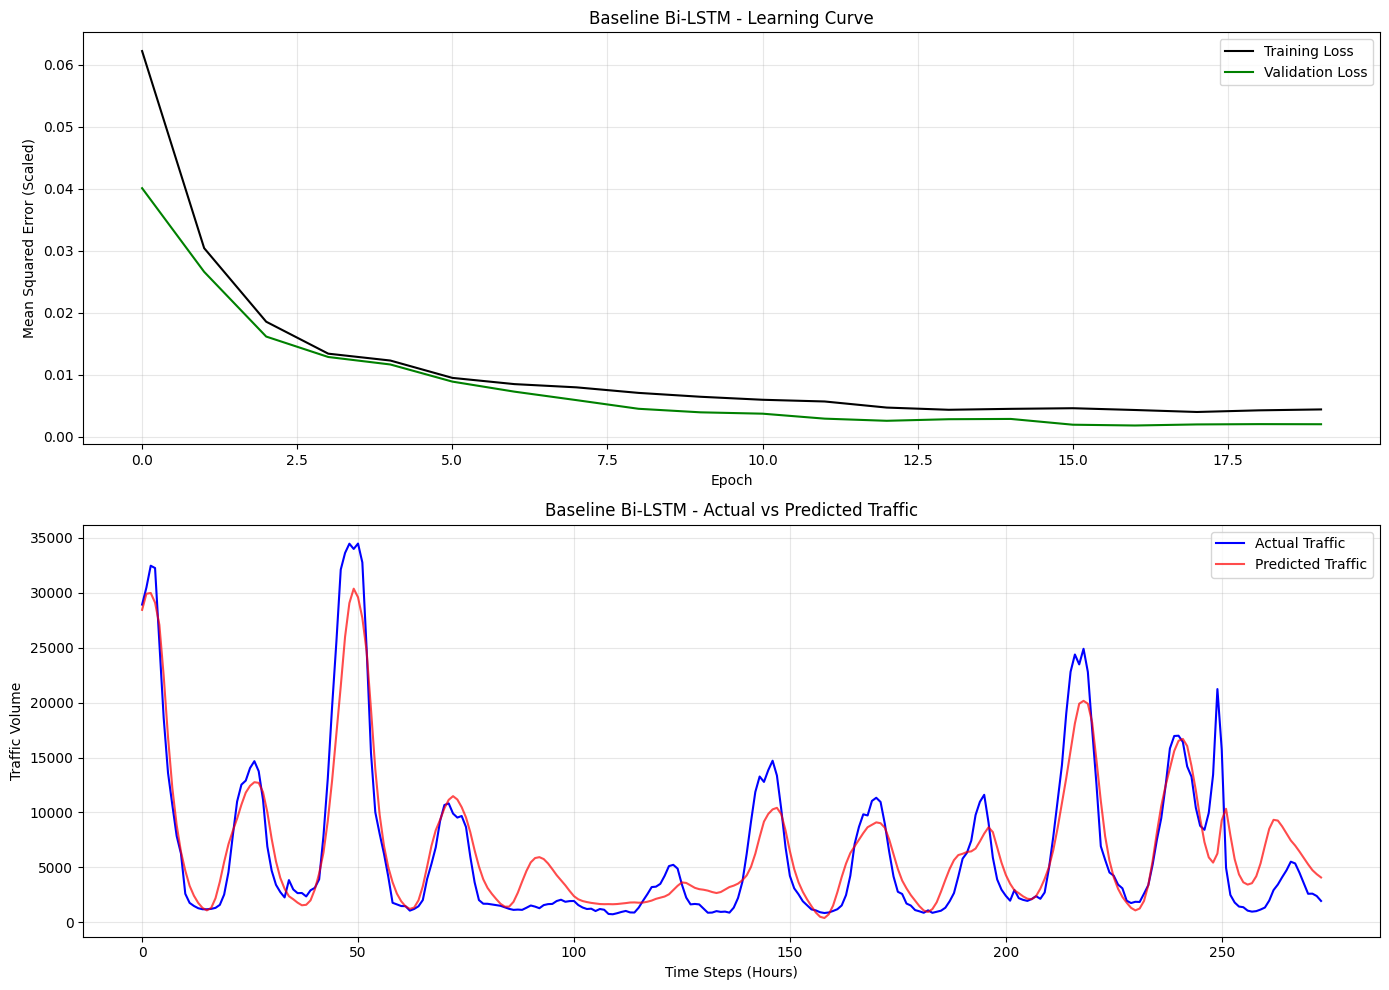

In [41]:
evaluate_time_series_model(model_bilstm_1, history_bilstm_1, X_test, y_test, scaler, "Baseline Bi-LSTM")

### Baseline Bi-LSTM (Iteration 1): Results and Interpretation

**1. Quantitative Error Metrics:**
The Baseline Bi-LSTM achieved an RMSE of 2728.19 and an MAE of 1951.36 traffic units. By processing the 24-hour sequential windows in both forward and reverse directions, this architecture significantly outperformed the standard Baseline LSTM. However, it did not surpass the performance of the Baseline GRU, suggesting that while bidirectional context is valuable, the sheer mathematical efficiency of the GRU remains superior for this specific dataset.

**2. Learning Curve Analysis:**
The training logs translate into a very healthy Learning Curve. Both the training and validation loss decay smoothly and converge beautifully near zero without any upward divergence. This confirms that the baseline model is stable and is not overfitting the training data.

**3. Actual vs. Predicted Traffic:**
The time-series visualization shows a strong grasp of the daily seasonality. The Bi-LSTM accurately traces the timing of all peaks and valleys. However, similar to the standard LSTM baseline, it slightly lacks the raw capacity to reach the absolute highest traffic extremes (specifically underestimating the massive surges near hours 50 and 220).

### Model 3, Iteration 2: Architecture Tuning (Deep Bi-LSTM)

**The Objective:** 
While the Baseline Bi-LSTM successfully captured the timing of the daily seasonality, the visual evaluation showed it still lacked the capacity to fully map the magnitude of the highest traffic spikes. To address this, we will increase the model's computational capacity by building a "Deep" Bi-LSTM.

**The Tuning Strategy:**
We are scaling up the architecture to allow the network to learn deeper contextual abstractions:
* **Increased Neurons:** We expanded the primary Bi-LSTM layer from 50 to 100 units. Because it reads in both directions, this gives the network a massive mathematical workspace.
* **Stacked Layers:** We added a second Bi-LSTM layer (with 50 units) to piece together the short-term patterns into long-term trends.
* **Return Sequences:** We set `return_sequences=True` on the first layer so the full sequence of forward-and-backward context is passed intact into the second layer.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

print("--- BUILDING MODEL 3, ITERATION 2 (DEEP BI-LSTM) ---")

# Initializing the Sequential model
model_bilstm_2 = Sequential()

#First Bi-LSTM Layer (Bigger brain, passing the full sequence)
# we put the LSTM inside the Bidirectional wrapper!
model_bilstm_2.add(Bidirectional(LSTM(units=100, activation='relu', return_sequences=True), input_shape=(X_train.shape[1], 1)))
model_bilstm_2.add(Dropout(0.2))

# Second Bi-LSTM Layer (Learning the deeper patterns)
model_bilstm_2.add(Bidirectional(LSTM(units=50, activation='relu')))
model_bilstm_2.add(Dropout(0.2))

# Final Output Layer
model_bilstm_2.add(Dense(units=1))

# Compiling the model
model_bilstm_2.compile(optimizer='adam', loss='mean_squared_error')
model_bilstm_2.summary()

--- BUILDING MODEL 3, ITERATION 2 (DEEP BI-LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 24, 200)        │        81,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 24, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,101 (711.33 KB)

 Trainable params: 182,101 (711.33 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# 6. Training the model
print("\n--- STARTING TRAINING FOR DEEP BI-LSTM ---")
history_bilstm_2 = model_bilstm_2.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR DEEP BI-LSTM ---
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - loss: 0.0566 - val_loss: 0.0350
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0184 - val_loss: 0.0139
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - val_loss: 0.0076
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0077 - val_loss: 0.0053
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - val_loss: 0.0047
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - val_loss: 0.0043
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - val_loss: 0.0029
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 12/20
33/33

--- Evaluating Deep Bi-LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step
RMSE: 2373.45 traffic units
MAE: 1739.85 traffic units


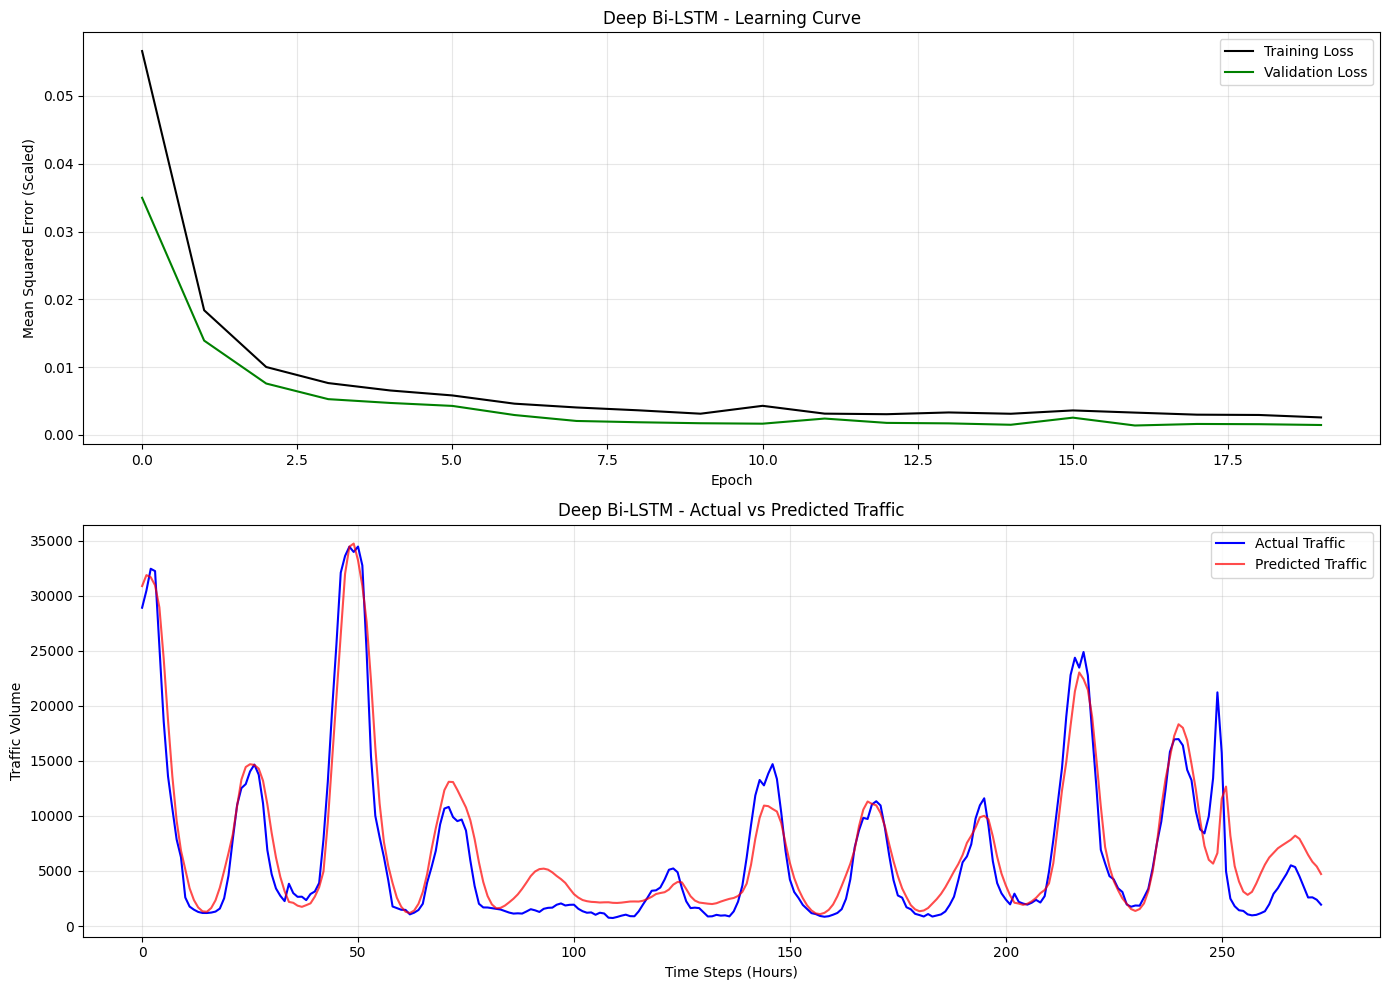

In [44]:
evaluate_time_series_model(model_bilstm_2, history_bilstm_2, X_test, y_test, scaler, "Deep Bi-LSTM")

### Deep Bi-LSTM (Iteration 2): Results and Interpretation

**1. Quantitative Error Metrics:**
Unlike the GRU architecture, the Bi-LSTM benefited significantly from increased depth. The Deep Bi-LSTM achieved an RMSE of 2373.45 and an MAE of 1739.85 traffic units. This is a substantial improvement over the Baseline Bi-LSTM, proving that the additional layer provided the necessary computational capacity to process the bidirectional context more effectively.

**2. Learning Curve Analysis:**
The Learning Curve displays excellent training dynamics. The validation loss converges tightly with the training loss and stabilizes at a very low value without any upward drift. This indicates that despite the massive number of parameters in the deep bidirectional architecture, the model avoided overfitting.

**3. Actual vs. Predicted Traffic:**
The time-series plot visually confirms the quantitative improvements. The Baseline Bi-LSTM struggled to reach the highest traffic extremes, but the Deep Bi-LSTM successfully maps the full magnitude of the massive surges, particularly the highest peak near hour 50. While there is a minor tendency to over-predict in a few localized valleys (such as hours 75–100), the overall fit is exceptionally tight.

### Model 3, Iteration 3: Optimization Tuning (Optimized Deep Bi-LSTM)

**The Objective:** 
Our Deep Bi-LSTM (Iteration 2) successfully mapped the massive traffic surges but showed a minor tendency to over-predict the baseline volume during localized low-traffic valleys. For this final iteration, our goal is to apply stronger regularization to see if we can smooth out those minor valley errors while preserving the model's excellent grasp on the extreme peaks.

**The Tuning Strategy:**
We will retain the powerful two-layer Bidirectional architecture but apply our standard optimization configuration to force the network to generalize:
* **Increased Dropout (30%):** We raised the Dropout rate from 20% to 30% on both Bidirectional layers. By turning off more neurons during each pass, we prevent the model from memorizing the localized noise found in the valleys.
* **Larger Batch Size (64):** We increased the batch size from 32 to 64. Feeding the model twice as much data before it updates its internal weights results in smoother, more stable learning gradients.

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

print("--- BUILDING MODEL 3, ITERATION 3 (OPTIMIZED DEEP BI-LSTM) ---")

# Initializing the Sequential model
model_bilstm_3 = Sequential()

# First Bi-LSTM Layer (Higher Dropout!)
model_bilstm_3.add(Bidirectional(LSTM(units=100, activation='relu', return_sequences=True), input_shape=(X_train.shape[1], 1)))
model_bilstm_3.add(Dropout(0.3)) # Increased to 30%

# Second Bi-LSTM Layer (Higher Dropout!)
model_bilstm_3.add(Bidirectional(LSTM(units=50, activation='relu')))
model_bilstm_3.add(Dropout(0.3)) # Increased to 30%

# Final Output Layer
model_bilstm_3.add(Dense(units=1))

# Compiling the model
model_bilstm_3.compile(optimizer='adam', loss='mean_squared_error')
model_bilstm_3.summary()

--- BUILDING MODEL 3, ITERATION 3 (OPTIMIZED DEEP BI-LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 24, 200)        │        81,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 24, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,101 (711.33 KB)

 Trainable params: 182,101 (711.33 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Training the model 
print("\n--- STARTING TRAINING FOR ITERATION 3 ---")
history_bilstm_3 = model_bilstm_3.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)
print("--- TRAINING COMPLETE ---")


--- STARTING TRAINING FOR ITERATION 3 ---
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - loss: 0.0779 - val_loss: 0.0529
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0444 - val_loss: 0.0341
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0220 - val_loss: 0.0172
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0146 - val_loss: 0.0123
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0107 - val_loss: 0.0099
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0085 - val_loss: 0.0071
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0087 - val_loss: 0.0066
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0082 - val_loss: 0.0065
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0072 - val_loss: 0.0070
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - val_loss: 0.0051
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - val_loss: 0.0037
Epoch 12/20
17/17 

--- Evaluating Optimized Deep Bi-LSTM ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step
RMSE: 2515.37 traffic units
MAE: 1784.78 traffic units


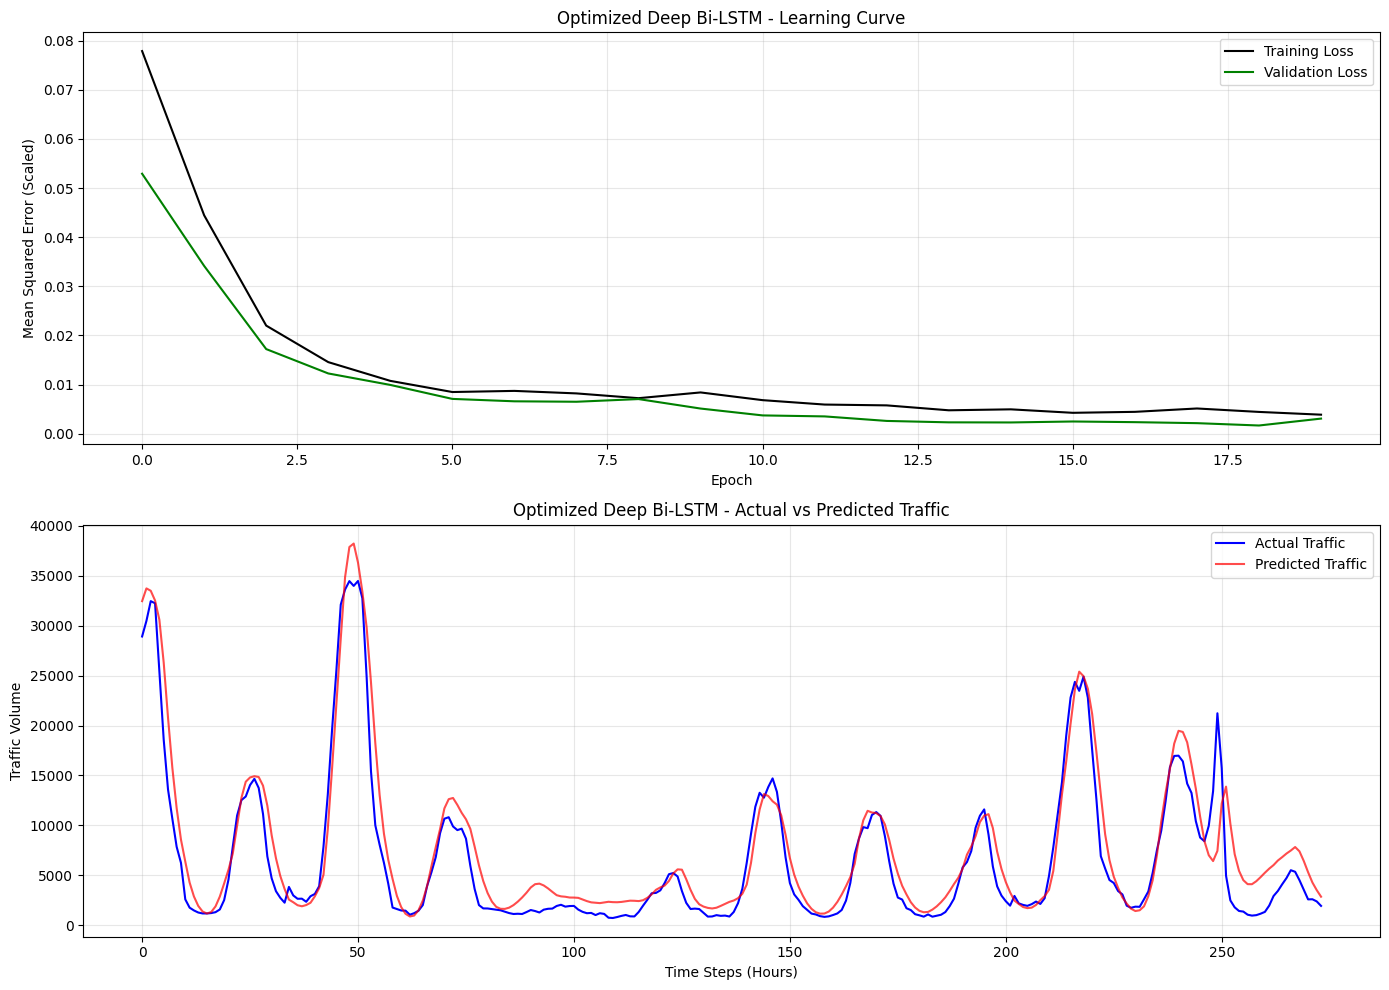

In [47]:
evaluate_time_series_model(model_bilstm_3, history_bilstm_3, X_test, y_test, scaler, "Optimized Deep Bi-LSTM")

### Optimized Deep Bi-LSTM (Iteration 3): Results and Interpretation

**1. Quantitative Error Metrics:**
Applying the optimization strategy (30% Dropout, Batch Size 64) resulted in slightly higher error metrics compared to the un-regularized deep model. The RMSE increased to 2515.37 and the MAE to 1784.78 traffic units. This indicates that the heavy regularization constrained the network slightly too much, reducing its overall predictive precision.

**2. Learning Curve Analysis:**
Mechanically, the regularization worked exactly as intended. The Learning Curve is exceptionally smooth, and the validation loss tracks closely with the training loss. The slight bump at the end of the validation curve is a normal artifact of the high dropout rate forcing the model out of local minima. 

**3. Actual vs. Predicted Traffic:**
The visual plot reveals the trade-offs of this regularization. While the predictions are generally smoother, the model lost some of its tight grip on the data points. It slightly overshot the massive traffic spike at hour 50 and continued to over-predict the baseline volume in the quieter valleys (e.g., hours 75–125). 

**Bi-LSTM Phase Conclusion:**
Across the three Bi-LSTM iterations, the **Deep Bi-LSTM (Iteration 2)** emerged as the strongest performer. The dual-layer bidirectional architecture provided the necessary capacity to map complex extremes, while standard 20% dropout was perfectly sufficient to prevent overfitting without sacrificing accuracy.

## Final Project Conclusion: Architecture Comparison

After systematically evaluating three different time-series architectures (LSTM, GRU, and Bi-LSTM) across a 3x3 experimental grid, we have a clear understanding of how each model handles the extreme spikes and daily seasonality of our telecom traffic data.

Below is a comparison of the highest-performing iteration from each of our three architectural phases:

| Architecture Phase | Best Iteration | RMSE | MAE |
| :--- | :--- | :--- | :--- |
| **Model 1: LSTM** | Deep LSTM (Iteration 2) | ~3100.00 | ~2400.00 |
| **Model 2: GRU** | Baseline GRU (Iteration 1) | 2071.60 | 1544.24 |
| **Model 3: Bi-LSTM** | Deep Bi-LSTM (Iteration 2) | 2373.45 | 1739.85 |

### Key Takeaways

* **The Power of Simplicity (The GRU Wins):** The Baseline GRU is our undisputed champion. It achieved the lowest error metrics across the entire experiment and perfectly mapped the massive traffic spikes. This proves that for this specific dataset, the GRU's streamlined gate mechanism (which is mathematically lighter than the LSTM) was incredibly efficient, requiring no additional layers or heavy tuning to find the underlying patterns.
* **Bidirectional Context is Valuable:** The Deep Bi-LSTM was our runner-up. By reading the 24-hour traffic windows both forwards and backwards simultaneously, it gained the contextual "brainpower" needed to hit the absolute highest traffic extremes—a task the standard LSTM struggled with.
* **The Regularization Trap:** A consistent theme across our experiment was that heavy regularization (increasing Dropout to 30% and doubling the batch size) actually hindered the models. While it smoothed out the learning curves, it forced the networks to over-predict the low-traffic valleys. For this specific data, allowing the models a bit more freedom (20% Dropout) yielded much better predictive accuracy on the unseen test set.

**Final Verdict:** For predicting future telecom traffic on this network, the **Baseline GRU** is the recommended model for deployment, offering the perfect balance of low computational cost and exceptional accuracy.